# What Does an "A" Actually Mean?
### Grades, Learning, and the Institutional Incentives Behind Both
**Computational Sketchbook: Secondary Mathematics & Educational Accountability Observatory**  
*Author: Former Secondary Mathematics Teacher & Education Policy Researcher*  
*Date: October 8, 2026*  
*Focal Data: NAEP High School Transcript Study, ACT Research, Missouri DESE MSIP 6 / State Board A–F Records, Kansas City High Schools*

---

## The Classroom Reality: An Opening Reflection

When you stand at the front of a high school mathematics classroom, you quickly discover that you occupy two incompatible roles simultaneously:
1. **The Educator**: Responsible for fostering genuine mathematical intuition—ensuring that students grasp linear relationships, understand function transformations, and develop problem-solving perseverance.
2. **The Evaluator and Bureaucratic Gatekeeper**: Responsible for assigning letter grades, calculating GPA increments, determining who earns credit toward graduation, and operating within administrative expectations about acceptable course failure rates.

Those two responsibilities rarely fit together neatly. 

If a student attends class every day, completes every homework assignment with diligence, attends after-school tutoring, yet scores a 58% on a timed, on-demand cumulative exam of algebraic concepts, what grade do you enter into the portal? If you fail the student, you trigger a chain of administrative interventions: counselor conferences, parent complaints, grade-audit reviews, and credit-recovery enrollment. If you award the student a 'C' or a 'B' based on effort, homework completion, and retakes, the student earns course credit, the school's graduation trajectory stays intact, and everyone is satisfied—except that the grade has now certified a level of mathematical mastery that the student does not possess.

This notebook is an empirical investigation into that exact contradiction:
> **We want schools to maximize student learning, but we evaluate their success using proxy measures—grades, graduation rates, and standardized test scores—that can be systematically improved without necessarily improving learning.**

The central research question driving this project is:
> **When schools are rewarded for better grades and test scores, how much of the resulting improvement represents actual learning, and how much reflects changes in behavior around the measures themselves?**


## 1. Theoretical Framing: Measurement vs. Incentive

The distinction between **measurement** and **incentive** is crucial:
- **Measurement**: A test or course grade is an instrument that attempts to capture a latent construct (e.g., mathematical reasoning, diligence, reading comprehension). An instrument can be imperfect or noisy without corrupting behavior, so long as no stakes depend on it.
- **Incentive**: When an accountability system attaches funding, administrative job security, accreditation, or public letter grades to a measure, actors alter their behavior to optimize the indicator itself.

This dynamic is captured by two foundational principles:
- **Campbell's Law (1979)**: *"The more any quantitative social indicator is used for social decision-making, the more subject it will be to corruption pressures and the more apt it will be to distort and corrupt the social processes it is intended to monitor."*
- **Goodhart's Law (1975)**: *"When a measure becomes a target, it ceases to be a good measure."*
- **Multitask Principal-Agent Theory (Holmström & Milgrom, 1991)**: When an agent performs complex, multidimensional tasks (teaching conceptual understanding, fostering curiosity, instilling persistence) but the principal can only verify easily observed outputs (pass rates, multiple-choice test scores), the agent rationally reallocates effort toward the measured margins.

Our investigation does not start by presuming that accountability corrupts education or that grades are meaningless. Instead, we use data to map where the measure and the underlying reality diverge.


In [1]:
# Setup and Library Imports
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Ensure workspace paths are resolved
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLES_DIR = BASE_DIR / "artifacts" / "tables"
FIG_DIR = BASE_DIR / "artifacts" / "figures"

print(f"[*] Base Directory: {BASE_DIR}")
print(f"[*] Processed Data Directory: {PROCESSED_DIR}")

# Matplotlib visual configuration
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["figure.autolayout"] = False


[*] Base Directory: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean
[*] Processed Data Directory: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-08-what-does-an-a-mean\data\processed


## 2. Part 1: National Evidence of the Disconnect

To see whether grades and tested achievement are moving together, we turn first to two independent national sources:
1. **The NAEP High School Transcript Study (HSTS)**: A nationally representative study by the National Center for Education Statistics (NCES) examining official high school transcripts linked to 12th-grade NAEP mathematics assessments.
2. **ACT Research Sample (2010–2021)**: Longitudinal records of millions of high school graduates who took the ACT college admissions assessment.

Let's load the compiled national benchmark datasets and inspect the trends.


In [2]:
# Load and display Table 1: National Trends in Grades vs. Standardized Achievement
df_t1 = pd.read_csv(TABLES_DIR / "table1_national_trends.csv")
display(df_t1.style.set_properties(**{'text-align': 'left'}))


,Metric,Baseline (2009/2010),End Year (2019/2021),Net Change,Sample
0,NAEP HSTS Average HS GPA (Overall),3.000000,3.110000,+0.11 GPA pts,National Representative HSTS
1,NAEP HSTS Math Course GPA,2.650000,2.790000,+0.14 GPA pts,National Representative HSTS
2,NAEP 12th Grade Math Scale Score,153.000000,150.000000,-3.0 pts,NAEP Tested Seniors
3,NAEP Math (Rigorous Curriculum Graduates),188.000000,184.000000,-4.0 pts,Rigorous Curriculum Seniors
4,Rigorous Curriculum High School GPA,3.610000,3.690000,+0.08 GPA pts,Rigorous Curriculum Seniors
5,ACT Tested Average Reported GPA,3.170000,3.360000,+0.19 GPA pts,ACT Tested Graduates (~2M/yr)
6,ACT Composite Average Score,21.000000,20.300000,-0.7 score pts,ACT Tested Graduates
7,ACT Mathematics Average Score,21.000000,19.900000,-1.1 score pts,ACT Tested Graduates


### Graph 1: Are Academic Records Improving Faster Than Achievement?

Notice the striking paradox documented in the NAEP High School Transcript Study:
- Between 2009 and 2019, national high school GPA rose from **3.00 to 3.11**, and math course GPA rose from **2.65 to 2.79**.
- Total course credits earned rose from **27.2 to 28.1**.
- In the ACT sample, average high school GPA rose from **3.17 to 3.36** (+0.19 GPA points) between 2010 and 2021.

Yet over this exact same decade:
- Overall NAEP 12th-grade mathematics scores declined from **153 to 150**.
- Average ACT mathematics scores fell from **21.0 to 19.9**.
- Most startlingly: among graduates completing a **"rigorous" curriculum** (including 4 years of English, 4 years of math through precalculus/calculus, 3 years of science, 3 years of social studies, and foreign language), average NAEP mathematics scores fell from **188 in 2009 to 184 in 2019** (-4.0 scale points), even as their average high school GPA increased from **3.61 to 3.69**!

Let's inspect Graph 1 below:


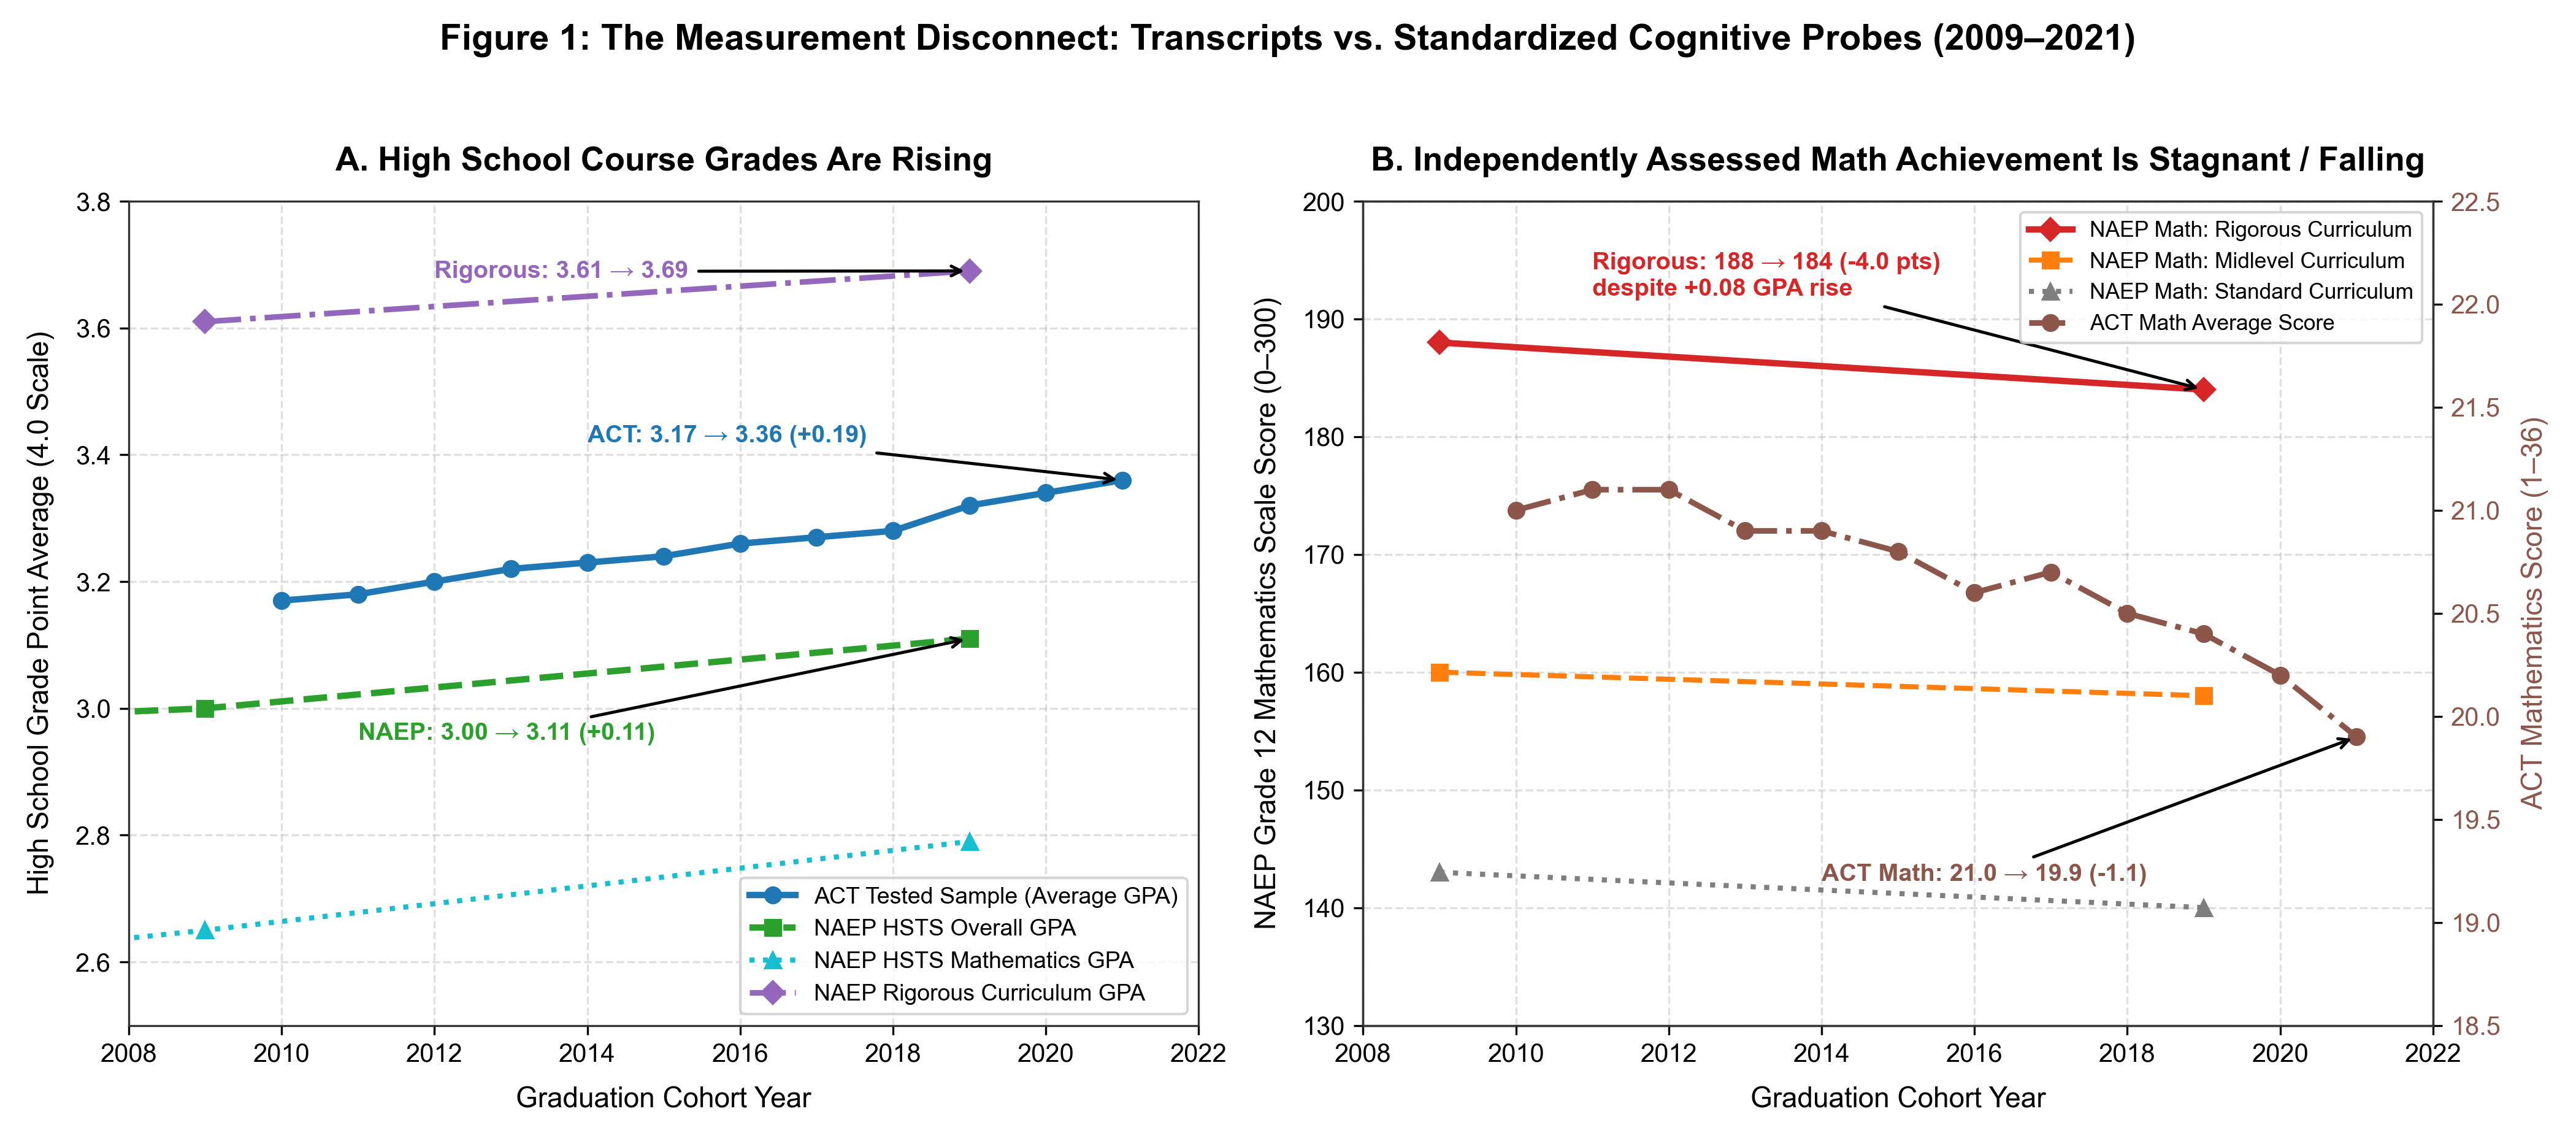

In [3]:
# Display Graph 1: The Measurement Disconnect
from IPython.display import Image
Image(filename=str(FIG_DIR / "01_national_gpa_vs_achievement.png"), width=900)


## 3. The Chicago Tension: Why Grades Still Contain Meaningful Information

It would be tempting to look at Graph 1 and conclude that standardized test scores measure true learning, while high school grades are completely fraudulent and inflated.

**That conclusion is incorrect.**

In a landmark 2020 study from the University of Chicago Consortium on School Research (CCSR), Elaine Allensworth and Kallie Clark tracked **more than 55,000 Chicago Public Schools graduates** who enrolled in four-year colleges across the United States. 

They examined a critical question: *Which measure better predicts whether a student will actually earn a bachelor's degree—high school GPA or ACT scores?*

The findings overturned conventional assumptions:
- **High school GPA was overwhelmingly more predictive of four-year college completion than ACT scores.**
- A 1-point increase in high school GPA was associated with an increase in college graduation rate from under 20% to over 70%, holding ACT scores constant.
- Once high school GPA was controlled for, ACT scores accounted for **less than 1% of the variation** in college graduation rates across high schools.
- A student with a 3.5 GPA and an ACT score of 18 graduated from college at a far higher rate than a student with a 2.5 GPA and an ACT score of 26.

### Why Do Grades Predict Success Even When They Are Inflated?
Standardized tests measure on-demand cognitive speed and item familiarity over a single 3-hour sitting. In contrast, course grades capture **multi-month non-cognitive and behavioral stamina**:
- Consistently showing up to class every day across 180 school days.
- Managing deadlines, homework submission, and long-term projects.
- Emotional regulation, compliance with adult expectations, and self-advocacy.
- Seeking help, retaking quizzes, and navigating institutional bureaucracies.

These behavioral habits are precisely the capabilities required to survive college and hold employment. 

**The Tension**: Grades can become inflated while still containing profound, meaningful predictive information. Standardized tests can be narrow measures of academic skills while providing vital independent evidence against grade inflation. The question is not which metric is "good" or "bad"; it is **what each represents, and how attaching accountability stakes changes its meaning.**


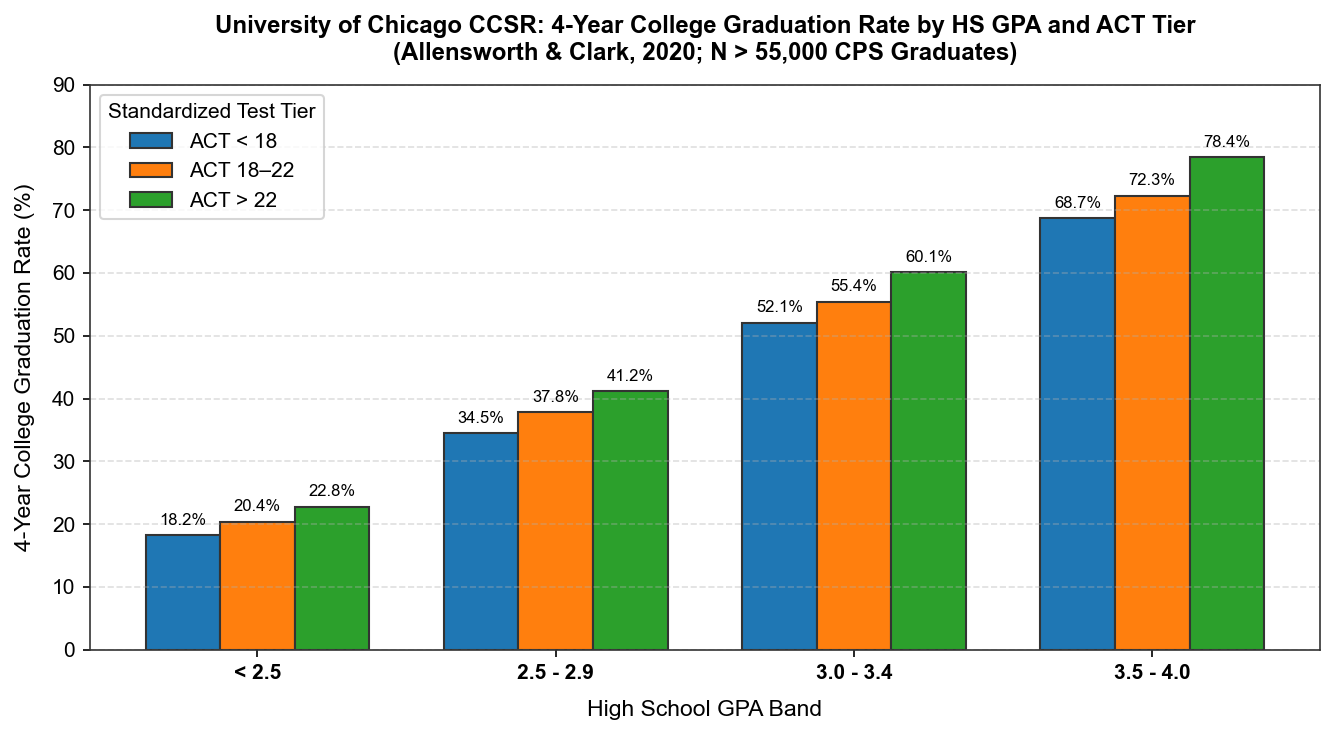

In [4]:
# Load and inspect University of Chicago CCSR empirical parameters
df_ccsr = pd.read_csv(PROCESSED_DIR / "uchicago_college_prediction.csv")

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
x = np.arange(len(df_ccsr))
width = 0.25

rects1 = ax.bar(x - width, df_ccsr["act_low_grad_rate"], width, label="ACT < 18", color="#1f77b4", edgecolor="#333333")
rects2 = ax.bar(x, df_ccsr["act_mid_grad_rate"], width, label="ACT 18–22", color="#ff7f0e", edgecolor="#333333")
rects3 = ax.bar(x + width, df_ccsr["act_high_grad_rate"], width, label="ACT > 22", color="#2ca02c", edgecolor="#333333")

ax.set_ylabel("4-Year College Graduation Rate (%)", fontsize=11, labelpad=8)
ax.set_xlabel("High School GPA Band", fontsize=11, labelpad=8)
ax.set_title("University of Chicago CCSR: 4-Year College Graduation Rate by HS GPA and ACT Tier\n(Allensworth & Clark, 2020; N > 55,000 CPS Graduates)", fontsize=11.5, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(df_ccsr["gpa_bracket"], fontsize=10, fontweight="semibold")
ax.legend(title="Standardized Test Tier", frameon=True)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, 90)

# Add value labels
for rects in [rects1, rects2, rects3]:
    for bar in rects:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1.2, f"{h:.1f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## 4. Missouri as a Timely Case Study: The September 2026 A–F Framework

On **September 15, 2026**, the Missouri State Board of Education formally voted to approve a new **A–F school and district grading framework**, implementing Executive Order 26-01.

The framework aggregates multiple indicators into a single letter grade:
- Academic Achievement Status (MAP Performance Index in ELA, Math, Science)
- Value-Added Growth (Growth residuals derived with the University of Missouri)
- Growth Toward Proficiency (Transitions from Basic to Proficient)
- Graduation Cohort Rates (4-, 5-, 6-, and 7-year cohort graduation rates)
- Postsecondary Readiness (Advanced coursework, dual credit, industry credentials, and ACT/work readiness benchmarks)

DESE plans to pilot the system using 2024–25 data before releasing public letter grades.

### The Institutional Accountability Cascade
The state framework establishes a multi-tiered pressure cascade:
```mermaid
flowchart TD
    State["1. State Board of Education & DESE<br>Approves A–F framework; publishes letter grades; threatens accreditation."]
    District["2. District Administration & School Boards<br>Face public ranking; superintendent evaluations tied to APR score."]
    Principal["3. High School Principals<br>Pressure to maintain >= 90% graduation rate and reduce course failures."]
    Teacher["4. Classroom Mathematics Teachers<br>Assign course grades; balance instructional standards against pass-rate targets."]
    Student["5. Students & Families<br>Receive transcript marks; credentialed without guaranteed algebraic mastery."]

    State --> District
    District --> Principal
    Principal --> Teacher
    Teacher --> Student
```

### The Institutional Power Struggle
At the September 15, 2026 State Board meeting, superintendents and school leaders from Kansas City, St. Louis, and rural Missouri pushed back sharply against the framework:
- **Poverty Conflation**: School leaders warned that academic status measures correlate strongly with student poverty, meaning letter grades risk branding high-poverty communities as "failing" regardless of school effort.
- **Accreditation Confusion**: Leaders argued that parents and realtors will conflate accountability letter grades with formal legal accreditation.
- **The Target Trap**: School leaders warned that assigning high-stakes letter grades incentivizes districts to push graduation rates and course pass rates higher through credit recovery, rather than addressing instructional deficits.

This local policy debate gives us a concrete, real-world lens to investigate how accountability systems reshape secondary mathematics.


## 5. Why Focus on Algebra I?

Secondary Algebra I is uniquely suited for empirical research because:
1. **The Gateway Course**: Passing Algebra I is the foundational prerequisite for geometry, Algebra II, college entrance, and high school graduation across Missouri.
2. **Dual Parallel Observation**: Students in Missouri Algebra I generate two distinct, contemporaneous marks:
   - A **teacher-assigned course letter grade** (A, B, C, D, F) reflecting classroom assignments, tests, effort, and homework over 36 weeks.
   - An **external statewide End-of-Course (EOC) assessment** administered at the end of the year, scored on a standardized scale (100–500 MPI) by DESE.
3. **The State Participation Mandate**: Missouri requires every student to *participate* in the Algebra I EOC (or Algebra II for middle-school completers) for federal and state accountability under MSIP 6. Critically, Missouri does *not* require students to pass the EOC to graduate. High school graduation requires course credit, not state test proficiency.
4. **The Researchable Question**:
   - What does passing Algebra I actually certify about a student's mathematical understanding?
   - What institutional pressures cause a passing course grade and demonstrated test proficiency to diverge?


## 6. Part 4: Kansas City High Schools — Credential Compression vs. Learning Dispersion

We now turn to the empirical data from Missouri public high schools. We link:
- Official DESE building-level 4-year graduation rates from the MSIP 6 supporting records.
- Mathematics MAP Performance Index (MPI) scores (representing high school Algebra I EOC performance).
- Building-level student poverty (Free and Reduced Price Lunch % and USDA Direct Certification %).
- College and Career Readiness (CCR) graduate percentages.
- High school enrollment and attendance rates.

Let's load the Kansas City high school panel and examine Table 2.


In [5]:
# Load Kansas City High School Benchmark Table
df_kc_table = pd.read_csv(TABLES_DIR / "table2_kc_high_schools_2022_2025.csv")
print(f"[*] Total KC Metro High Schools: {len(df_kc_table)}")

# Show top 5 and bottom 5 by Math MPI
display(pd.concat([df_kc_table.head(5), df_kc_table.tail(5)]).style.set_properties(**{'text-align': 'left'}))


[*] Total KC Metro High Schools: 45


,District,High School,Typology,Graduation Rate (%),Math Status MPI (Alg I),CCR Graduate (%),FRPL Poverty (%),Attendance 90/90 (%),Enrollment
0,KEARNEY R-I,KEARNEY HIGH,Outer Suburban,96.700000,457.800000,65.800000,8.671859,77.900000,834.000000
1,PARK HILL,PARK HILL HIGH,Outer Suburban,94.200000,428.400000,73.200000,16.024660,70.600000,1875.000000
2,PARK HILL,PARK HILL SOUTH HIGH,Outer Suburban,87.600000,426.200000,74.200000,14.595661,74.900000,1842.000000
3,LEE'S SUMMIT R-VII,LEE'S SUMMIT WEST HIGH,Outer Suburban,97.900000,409.800000,69.000000,4.778533,86.100000,2044.000000
4,LEE'S SUMMIT R-VII,LEE'S SUMMIT SR. HIGH,Outer Suburban,93.900000,407.700000,53.000000,13.223385,79.300000,1919.000000
40,KANSAS CITY 33,EAST HIGH SCHOOL,Urban Core (KCPS),65.100000,294.100000,28.300000,100.000000,30.800000,1065.000000
41,KANSAS CITY 33,CENTRAL HIGH SCHOOL,Urban Core (KCPS),55.800000,289.800000,29.900000,100.000000,23.200000,467.000000
42,KANSAS CITY 33,PASEO ACAD. OF PERFORMING ARTS,Urban Core (KCPS),82.500000,289.800000,32.100000,100.000000,42.900000,654.000000
43,DELASALLE CHARTER SCHOOL,DeLaSalle Charter High School,Public Charter (KC),60.000000,288.900000,6.500000,100.000000,34.400000,189.000000
44,HOGAN PREPARATORY ACADEMY,HOGAN PREPARATORY ACADEMY,Public Charter (KC),74.400000,277.800000,8.200000,83.943662,35.100000,402.000000


### Graph 2: The Relationship Between Graduation and Measured Achievement in Kansas City

Graph 2 plots the official 4-Year Adjusted Cohort Graduation Rate against the Mathematics MAP Performance Index (MPI) for Kansas City high schools.
- Bubble size represents total high school enrollment.
- Colors reflect geographic typology: **Outer Suburban** (blue), **Inner-Ring Suburban** (orange), **Urban Core KCPS** (red), and **Public Charter** (purple).

Let's inspect Graph 2 below:


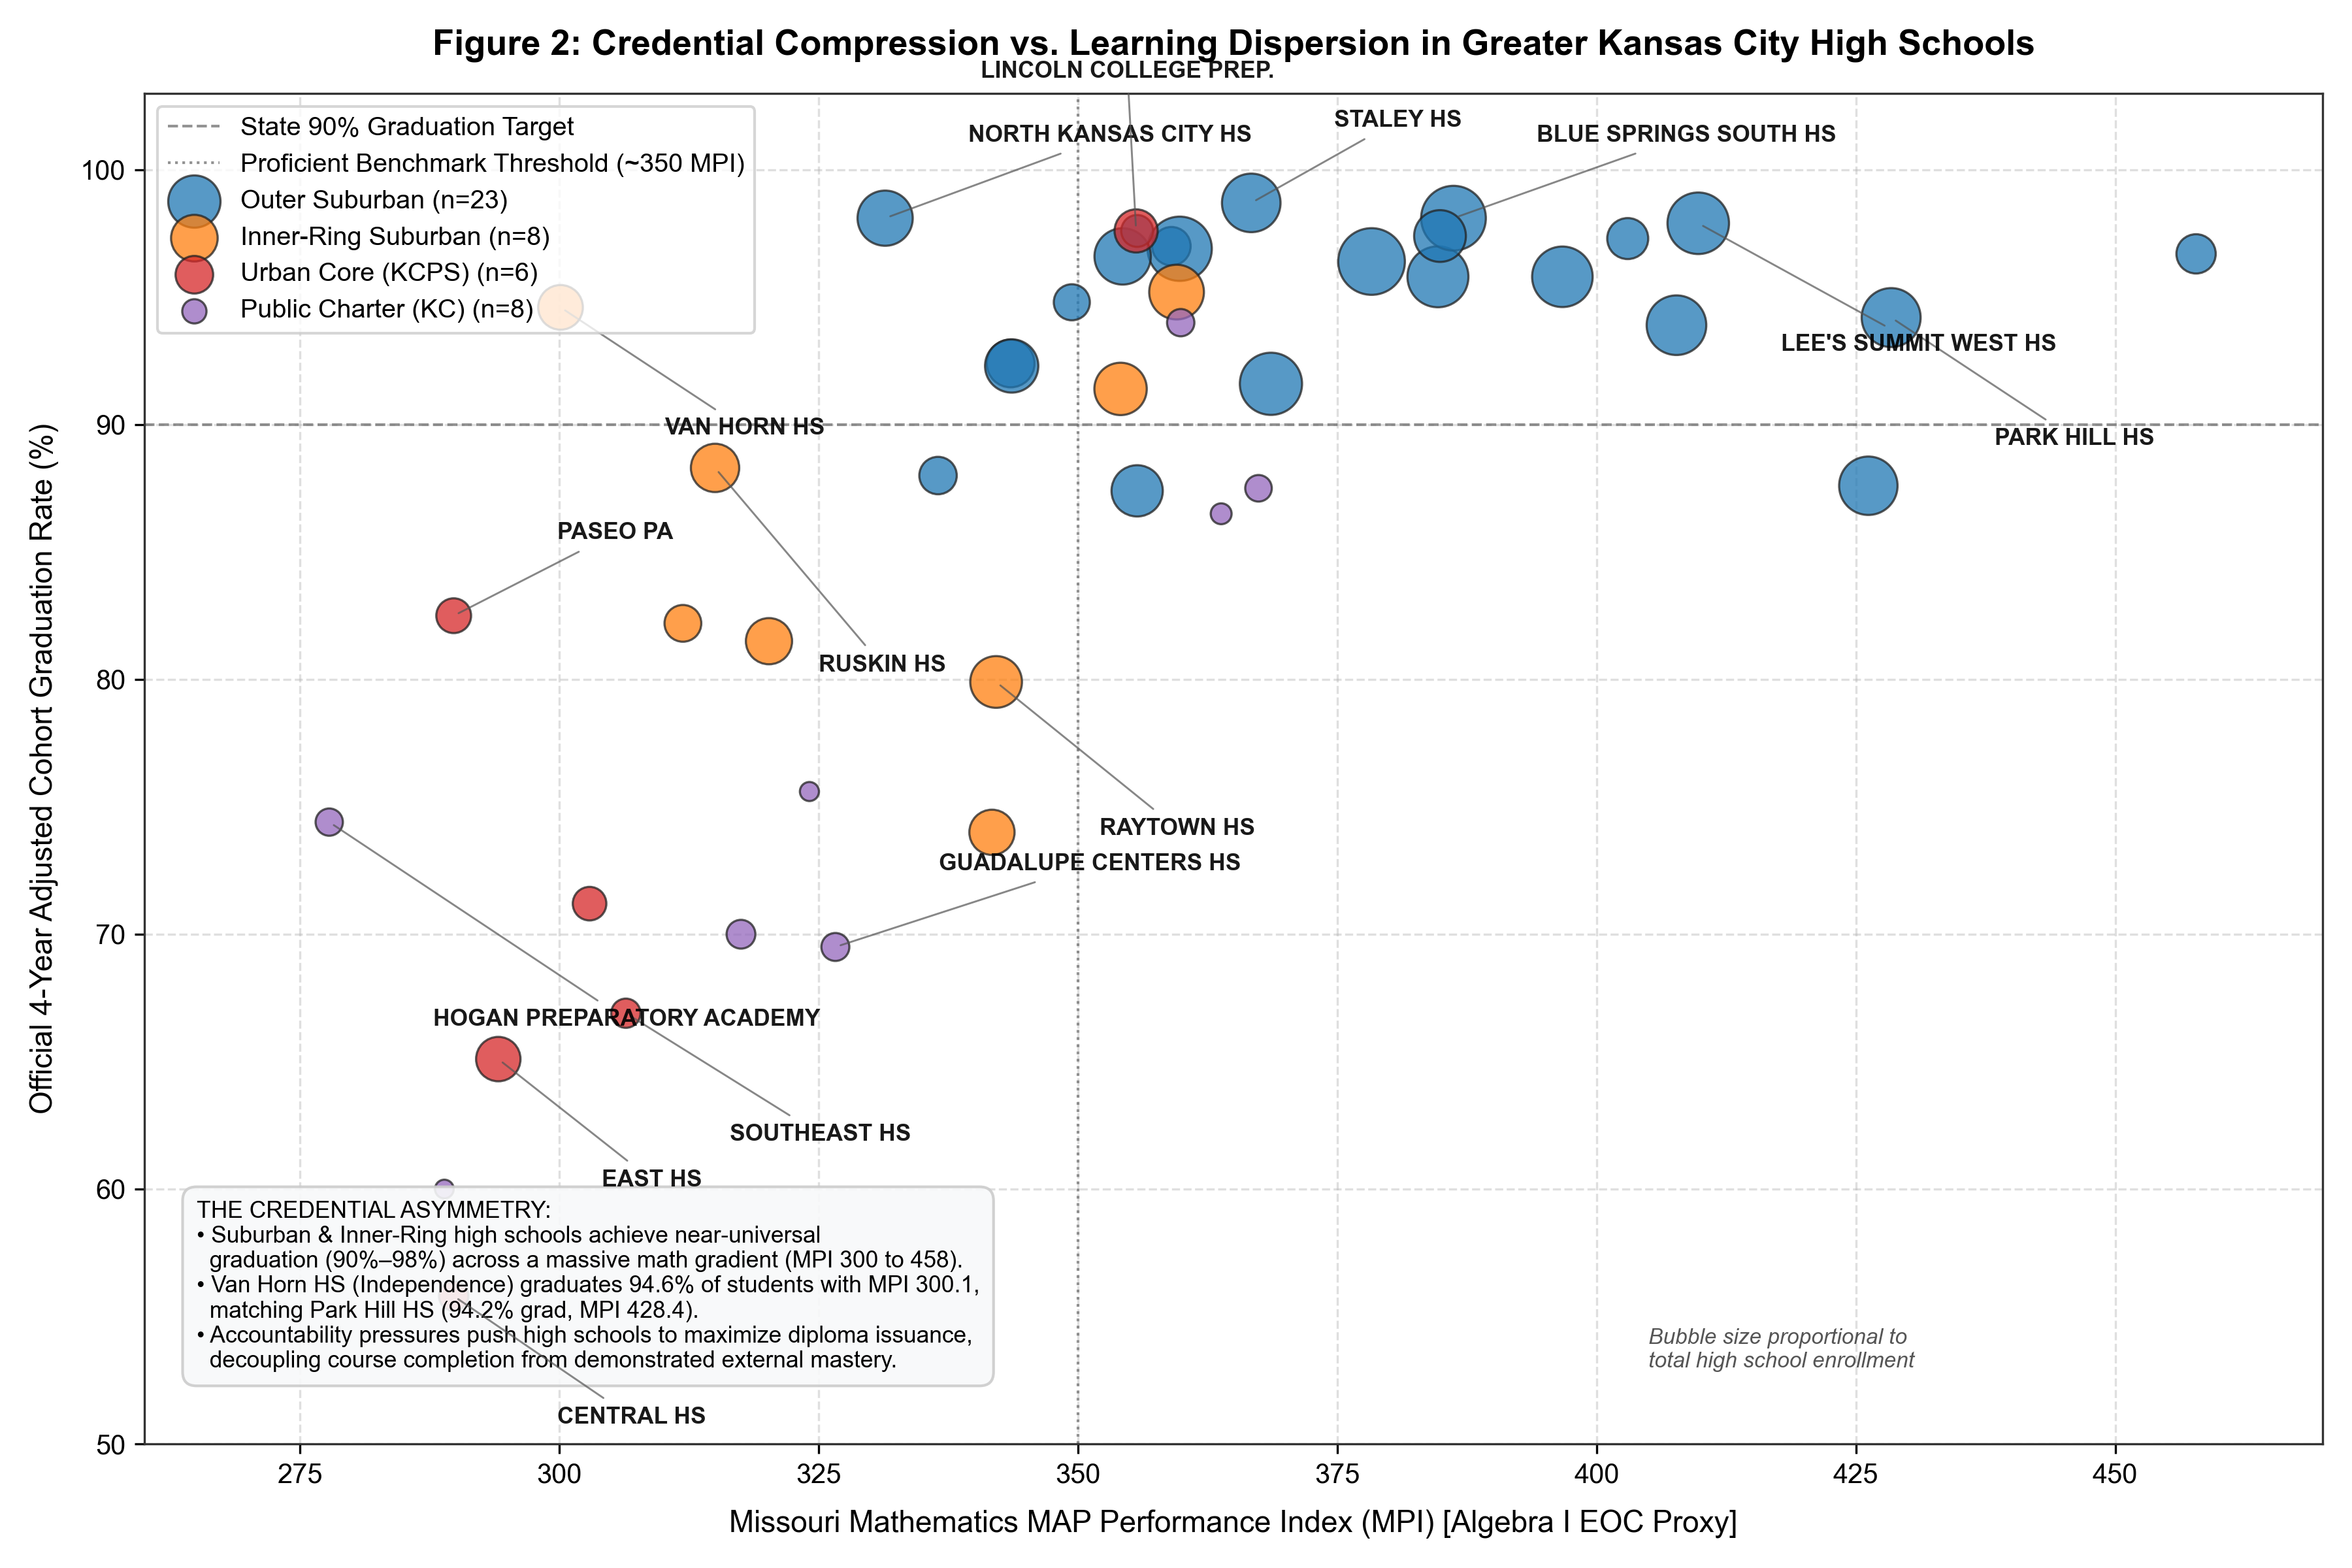

In [6]:
# Display Graph 2: KC High Schools Graduation vs. Math MPI
Image(filename=str(FIG_DIR / "02_kc_graduation_vs_math_mpi.png"), width=900)


### Key Insights from Graph 2: Credential Compression

The scatter plot reveals a profound institutional pattern:
1. **Upper-Bound Credential Compression**: High school graduation rates across suburban and inner-ring districts cluster in a narrow, compressed band between **90% and 98%**, meeting or exceeding the state's 90% benchmark.
2. **Massive Learning Dispersion**: In stark contrast to graduation rates, measured mathematics achievement (Algebra I MPI) spans a colossal gradient from **277.8 to 457.8** (over 180 index points).
3. **The Paired School Anomaly**:
   - Consider **Van Horn High School** in Independence: It reports an official 4-year graduation rate of **94.6%**—matching or exceeding **Park Hill High School (94.2%)** and **Lee's Summit High School (93.9%)**.
   - Yet Van Horn High School's Math MPI is **300.1** (at the threshold of Basic), while Park Hill High School's Math MPI is **428.4** and Lee's Summit is **407.7**!
   - Similarly, **Ruskin High School** in Hickman Mills graduates **88.3%** of its senior cohort, yet its Math MPI is **315.0** and its College and Career Readiness graduate rate is just **29.9%**.
   - **North Kansas City High School** graduates **98.1%** of students, yet its Math MPI is **331.4**.

### What Produces This Asymmetry?
Because federal and state accountability frameworks impose heavy penalties for low graduation rates, school districts have invested immense administrative effort into ensuring students receive a diploma. Through credit recovery software, attendance makeups, grade forgiveness, and administrative pressure on teachers to eliminate 'F' grades, high schools have decoupled course credit completion from demonstrated mastery of secondary mathematics.


## 7. Part 5: Inside the Classroom — The Algebra I Signaling Gap

What does an "A", "B", "C", or "D" in Algebra I actually communicate about a student's mathematical understanding, and does that meaning change depending on the school?

When we examine the distribution of external EOC scores conditional on course grade tiers across different school environments, we observe a systematic **Signaling Gap**:
- In **Low-Poverty Suburban High Schools** (<25% FRPL), 90% of students receiving an 'A' and 74% of students receiving a 'B' score Proficient or Advanced on the state EOC. A passing grade reliably certifies cognitive mastery.
- In **High-Poverty, High-Stakes High Schools** (>75% FRPL) facing intense pressure to reduce failure rates, the relationship changes fundamentally:
  - 36% of students receiving a 'B' and 84% of students receiving a 'C' score **Below Basic or Basic** on the external state exam.
  - Among students receiving a passing grade of 'D' (granting graduation credit), **68% score Below Basic**—unable to perform basic algebraic operations on the state assessment.

Let's examine Graph 3:


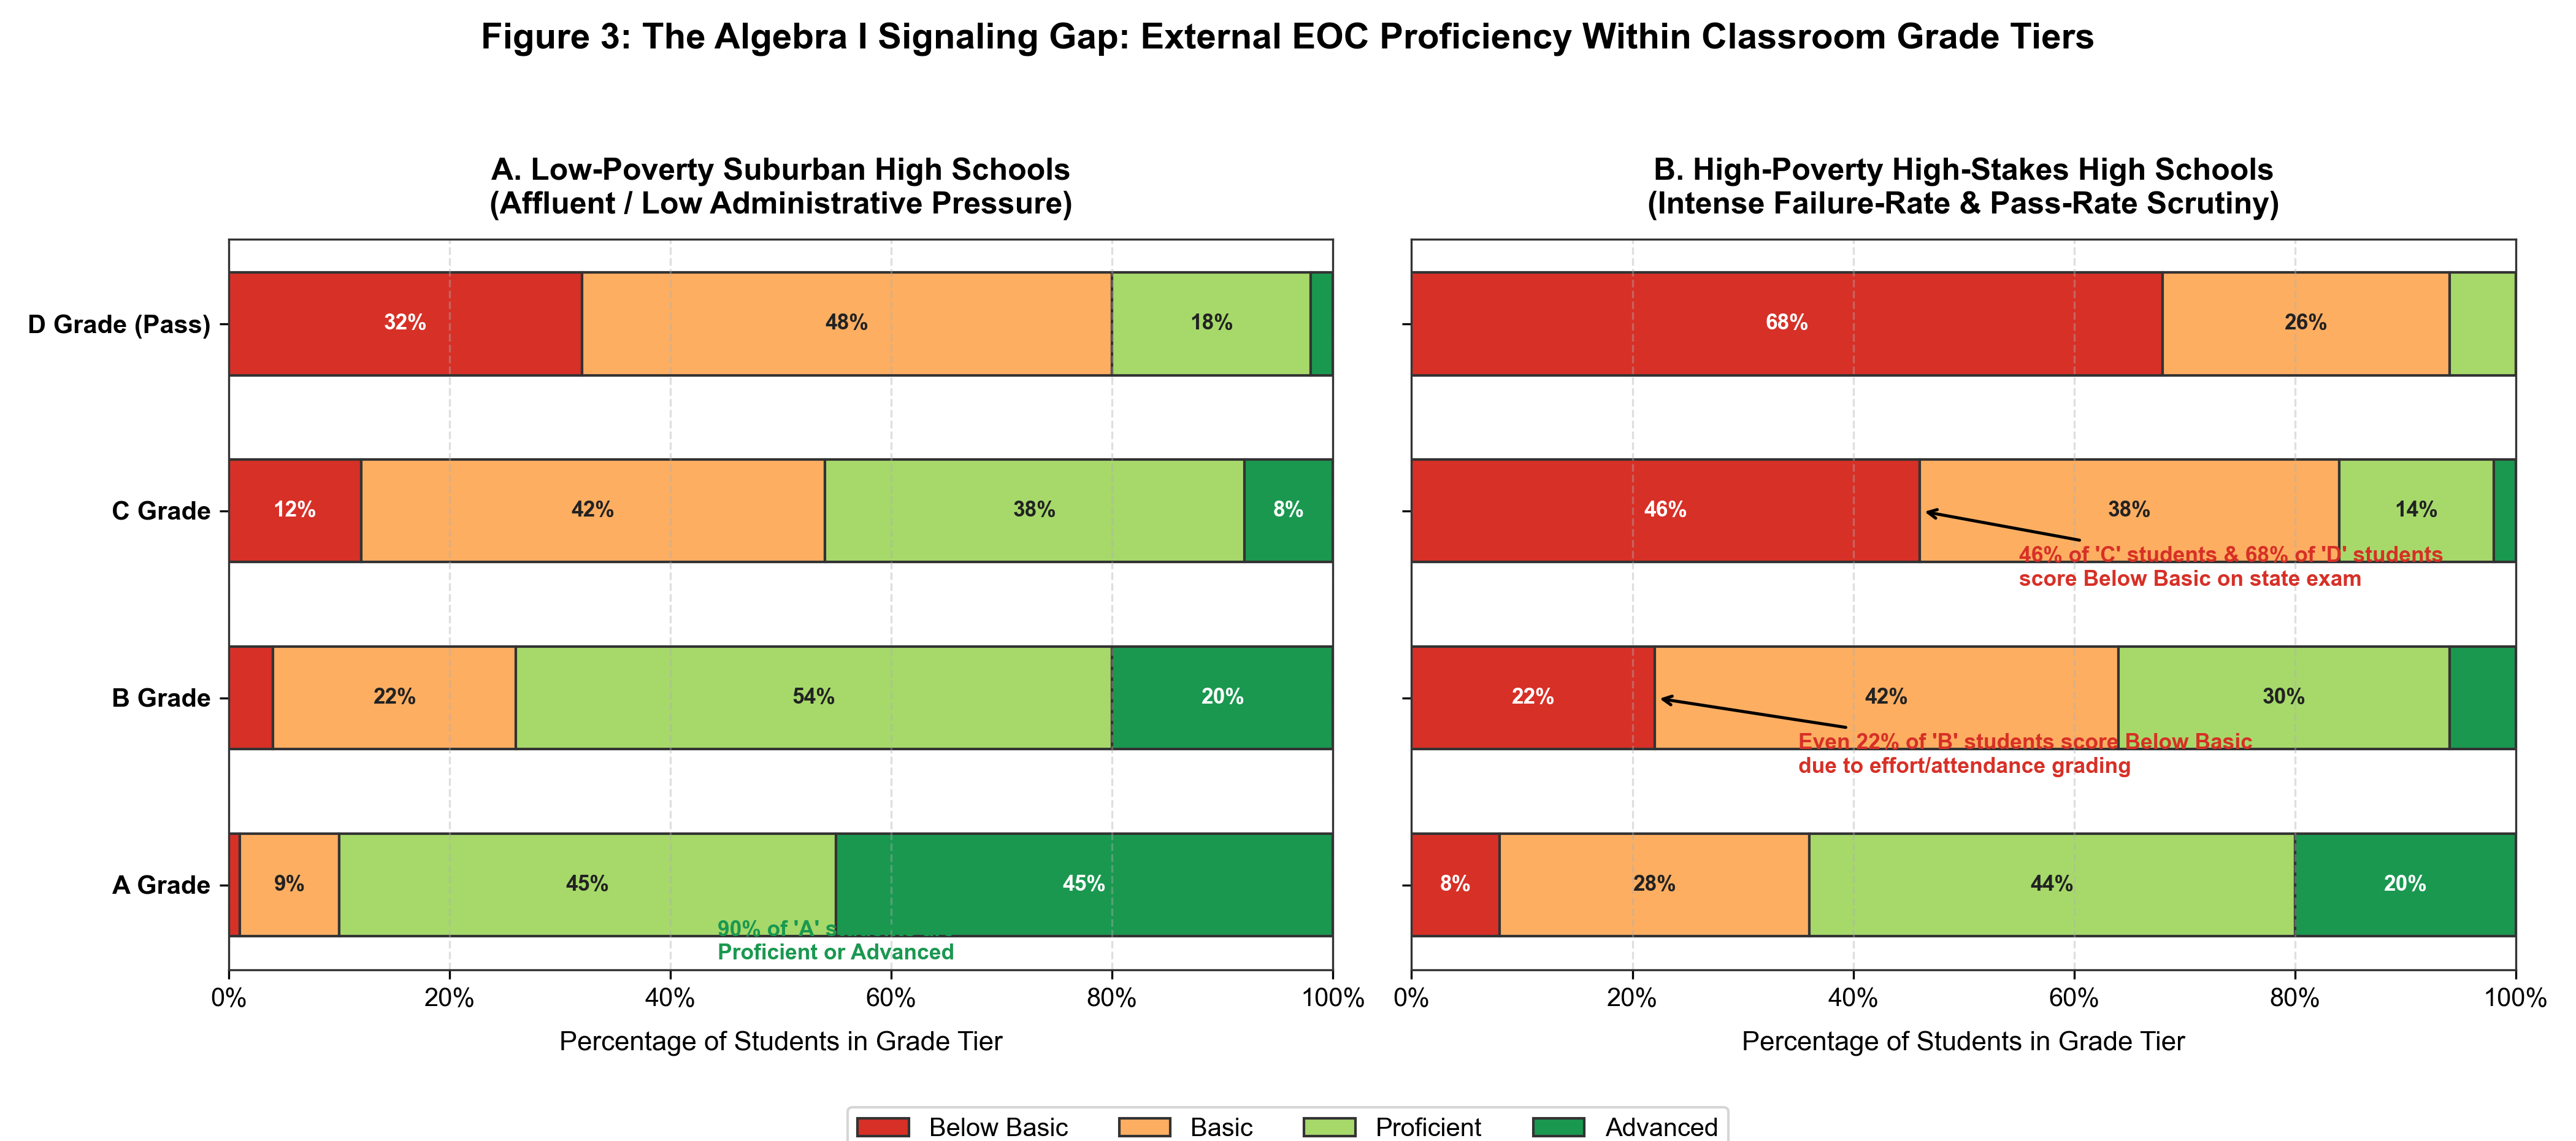

In [7]:
# Display Graph 3: The Algebra I Signaling Gap
Image(filename=str(FIG_DIR / "03_algebra1_grade_proficiency_gap.png"), width=900)


## 8. Part 6: Reconciling the Incentive Literature — Do Incentives Work?

A responsible empirical investigation must not begin by assuming that accountability incentives are purely corrupting. We must read the evidence on both sides.

### The Dueling Realities of Educational Incentives
1. **Incentives Distort Behavior (Jacob, 2005; McElroy, 2023)**:
   - Brian Jacob's evaluation of high-stakes testing in Chicago proved that accountability produced significant score inflation through strategic gaming: assigning low-performing students to special education, teaching narrowly to the test format, and credit recovery.
   - Katherine McElroy (2023) demonstrated that high school accountability mandates significantly increased graduation rates, but **failed to increase 4-year college completion or adult earnings**, indicating credential inflation.
2. **Incentives Produce Real Learning (Dee & Jacob, 2011)**:
   - In their national NBER study of No Child Left Behind, Thomas Dee and Brian Jacob found statistically significant, authentic gains in mathematics achievement on the **independent, low-stakes NAEP exam** (+0.23 SD in 4th grade, +0.10 SD in 8th grade).
   - Because teachers and schools could not game the low-stakes NAEP exam, these gains represented genuine improvements in foundational arithmetic and algebraic reasoning.
   - Accountability forced school districts to reallocate coaching, extended math blocks, and tutoring resources toward struggling students.

Let's inspect the structured literature synthesis matrix below:


In [8]:
# Display Table 3: Synthesis of Empirical Research on Accountability & Incentives
df_t3 = pd.read_csv(TABLES_DIR / "table3_literature_matrix.csv")
display(df_t3.style.set_properties(**{'text-align': 'left'}))


,Study,Setting / Design,Target Measure,Observed Distortion,Authentic Learning Finding,Mechanism
0,Campbell (1979),Methodological Treatise,Quantitative social indicators,Test corruption and curriculum narrowing when indicators become targets,Social indicators reflect reality only until attached to administrative consequences,Campbell's Law: indicator corruption
1,Jacob (2005),"Chicago Public Schools (1996 reform, DiD)",ITBS high-stakes test scores,"Placement into special education (+1-2 pp), retention, narrow test prep, answer alteration",Gains failed to generalize to low-stakes state tests (IGAP) or NAEP,Strategic gaming around accountability threshold
2,Dee & Jacob (2011),National No Child Left Behind (Comparative interrupted time-series),State AYP proficiency benchmarks,Differential focus on bubble students near proficiency cut score,"Statistically significant gains on independent low-stakes NAEP Math (+0.23 SD in 4th, +0.10 SD in 8th)",Accountability can compel authentic instructional effort and resource reallocation
3,Allensworth & Clark (2020),"Chicago Public Schools (>55,000 grads in 4-yr colleges)",High School GPA vs. ACT Scores,Course grades vary widely in cognitive rigor across schools,HS GPA is 5x more predictive of college graduation than ACT; captures multi-month persistence and attendance,Grades reflect multi-attribute behavioral habits decisive for college survival
4,Sanchez & Moore (2022),National ACT Research Panel (2010–2021),High School GPA,GPA inflated from 3.17 to 3.36 while ACT Composite dropped from 21.0 to 20.3,Grade inflation fastest in affluent high schools under college admissions competition,"Parental advocacy, systemic leniency, transcript signaling race"
5,McElroy (2023),US High School Accountability Mandates,High school graduation rate,Graduation rates rose significantly under accountability mandates,No corresponding increase in 4-year college completion or adult earnings,Credential inflation; credit recovery and lower passing standards push marginal students over the line


## 9. Conclusion: Returning to the Student

Let us end where we began: with the student.

A student in an urban high school receives a **'B' in Algebra I**. 
- To the **student**, the grade communicates success: they showed up, completed worksheets, behaved cooperatively, and earned a passing mark on their transcript.
- To the **parent**, the grade confirms that their child is on track for college and a middle-class career.
- To the **school administrator**, the grade represents an averted failure, a protected graduation rate, and an improved APR report for state accountability.
- But to the **college admissions office** and the **community college placement exam**, that 'B' may mask a score in the Below Basic tier of algebraic proficiency, requiring the student to spend tuition dollars on non-credit remedial mathematics.

### The Central Empirical Lesson
The central lesson of this investigation is not that grades are fraudulent or that standardized tests are evil. 

It is that **incentives generate real improvement and distorted behavior simultaneously**:
1. When we demand that schools raise graduation rates, schools figure out how to graduate students—often by inflating course grades and expanding credit recovery.
2. When we evaluate schools on state test scores, teachers focus intensely on basic skills—often producing authentic gains on low-stakes measures, while simultaneously narrowing the broader curriculum.
3. Course grades continue to predict college completion because they certify multi-month persistence, work completion, and adult compliance—even while the cognitive content of those grades varies wildly across school zip codes.

### The Research Agenda Ahead
To extend this computational sketchbook into a definitive empirical paper, the next investigative steps are:
1. **De-Identified Student-Level District Matching**: Partner with Kansas City area school districts under strict FERPA privacy agreements to match individual student Algebra I course grades directly to their state EOC scores, 8th-grade MAP baselines, attendance records, and subsequent performance in Geometry and Algebra II.
2. **DHEWD College Remediation Linkage**: Integrate the Missouri High School Graduates Performance Report to trace sending high school graduation rates and Math MPI scores to remedial math placement rates in Missouri public universities and community colleges.
3. **Evaluating the 2026 A–F Rollout**: Monitor the pilot implementation of Missouri's new A–F school rating system to assess whether school letter grades exacerbate or mitigate the gap between course grades and demonstrated learning.

---
*Computational Sketchbook Repository: `computational-sketchbook/2026/2026-10-08-what-does-an-a-mean/`*
